In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
data = {
    "text": [
        # Sports
        "The team scored a last minute goal to win the championship match",
        "The striker missed an easy penalty in the final minutes of the game",
        "Our national cricket team won the world cup after a thrilling final",
        "The tennis player won three consecutive grand slam titles this year",
        "The coach praised the defense for a strong performance in the tournament",
        "He broke the world record in the 100 meter sprint at the olympics",
        "The basketball team signed a new star player before the season started",
        "Fans cheered as the underdog team defeated the reigning champions",
        "The marathon runner trained for months before completing the race",
        "The referee awarded a penalty kick in the closing seconds of the match",

        # Technology
        "The new smartphone features a faster processor and improved camera",
        "Researchers developed an artificial intelligence model that writes code",
        "The startup launched a cloud platform for storing large datasets",
        "Engineers built a robot that can navigate complex indoor environments",
        "The company released a software update fixing several security bugs",
        "Scientists are using machine learning to predict protein structures",
        "The laptop comes with a longer battery life and a lighter design",
        "A new chip promises to double the speed of graphics rendering",
        "The app uses natural language processing to summarize long articles",
        "Developers are excited about the new programming language features",

        # Food
        "The chef prepared a delicious pasta dish with fresh basil and tomatoes",
        "This recipe calls for two cups of flour and a pinch of salt",
        "The bakery is famous for its warm chocolate chip cookies",
        "She grilled the vegetables and served them with a tangy sauce",
        "The restaurant added a new spicy curry to its dinner menu",
        "He roasted the chicken with garlic, rosemary, and lemon",
        "The smoothie recipe combines banana, strawberries, and yogurt",
        "The soup was simmered slowly to bring out a rich, savory flavor",
        "They tasted several cheeses paired with a glass of red wine",
        "The dessert menu features a creamy caramel flan and fresh fruit tart",

        # Politics
        "The senator proposed a new bill to reform healthcare policy",
        "Voters lined up early to cast their ballots in the general election",
        "The president signed an executive order on climate change today",
        "The parliament debated the new tax legislation for several hours",
        "The opposition party criticized the government's economic policy",
        "Officials met to discuss trade agreements between the two nations",
        "The mayor announced a new budget plan for public infrastructure",
        "The committee held hearings on proposed changes to immigration law",
        "The prime minister addressed the nation regarding the new reforms",
        "Campaign rallies were held across the country ahead of the election",
    ],
    "category": (
        ["Sports"] * 10 +
        ["Technology"] * 10 +
        ["Food"] * 10 +
        ["Politics"] * 10
    ),
}

df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (40, 2)


,text,category
0,The team scored a last minute goal to win the ...,Sports
1,The striker missed an easy penalty in the fina...,Sports
2,Our national cricket team won the world cup af...,Sports
3,The tennis player won three consecutive grand ...,Sports
4,The coach praised the defense for a strong per...,Sports
5,He broke the world record in the 100 meter spr...,Sports
6,The basketball team signed a new star player b...,Sports
7,Fans cheered as the underdog team defeated the...,Sports
8,The marathon runner trained for months before ...,Sports
9,The referee awarded a penalty kick in the clos...,Sports


In [3]:
df['category'].value_counts()

category
Sports        10
Technology    10
Food          10
Politics      10
Name: count, dtype: int64

In [4]:
def clean_text(text):
    """Lowercase, remove punctuation/digits, and collapse extra whitespace."""
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head()

,text,clean_text
0,The team scored a last minute goal to win the ...,the team scored a last minute goal to win the ...
1,The striker missed an easy penalty in the fina...,the striker missed an easy penalty in the fina...
2,Our national cricket team won the world cup af...,our national cricket team won the world cup af...
3,The tennis player won three consecutive grand ...,the tennis player won three consecutive grand ...
4,The coach praised the defense for a strong per...,the coach praised the defense for a strong per...


In [5]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_text"], df["category"],
    test_size=0.25, random_state=42, stratify=df["category"]
)

print(f"Train size: {len(X_train_text)}, Test size: {len(X_test_text)}")

Train size: 30, Test size: 10


In [6]:
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=2000
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print(f"TF-IDF matrix shape (train): {X_train.shape}")
print(f"TF-IDF matrix shape (test): {X_test.shape}")

TF-IDF matrix shape (train): (30, 362)
TF-IDF matrix shape (test): (10, 362)


In [7]:
knn = KNeighborsClassifier(n_neighbors=5, metric="cosine")
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.600

Classification Report:

              precision    recall  f1-score   support

        Food       1.00      0.33      0.50         3
    Politics       0.50      1.00      0.67         2
      Sports       0.60      1.00      0.75         3
  Technology       0.00      0.00      0.00         2

    accuracy                           0.60        10
   macro avg       0.53      0.58      0.48        10
weighted avg       0.58      0.60      0.51        10



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


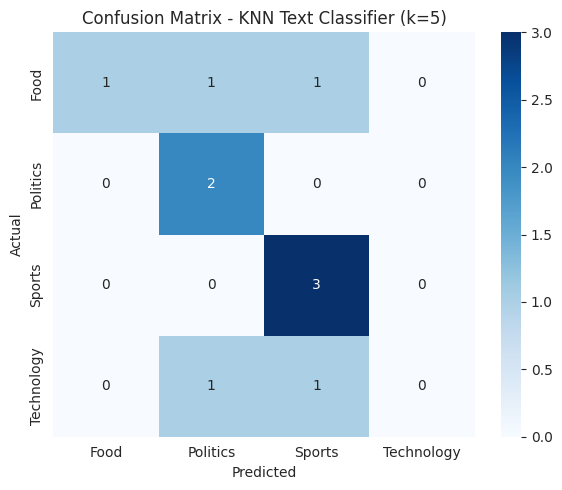

In [8]:
labels = sorted(df["category"].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN Text Classifier (k=5)")
plt.tight_layout()
plt.savefig("confusion_matrix_k5.png", dpi=150)
plt.show()

Best k found: 1 (CV accuracy = 0.467)


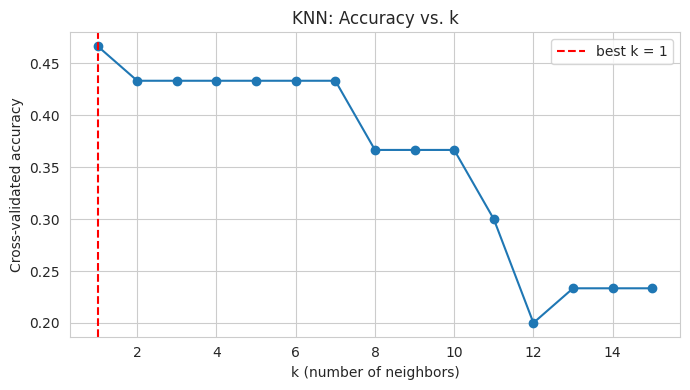

In [9]:
k_values = list(range(1, 16))
cv_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, metric="cosine")
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

best_k = k_values[int(np.argmax(cv_scores))]
print(f"Best k found: {best_k} (CV accuracy = {max(cv_scores):.3f})")

plt.figure(figsize=(7, 4))
plt.plot(k_values, cv_scores, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"best k = {best_k}")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Cross-validated accuracy")
plt.title("KNN: Accuracy vs. k")
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_vs_k.png", dpi=150)
plt.show()

In [10]:
best_knn = KNeighborsClassifier(n_neighbors=best_k, metric="cosine")
best_knn.fit(X_train, y_train)

y_pred_best = best_knn.predict(X_test)

print(f"Final Accuracy (k={best_k}): {accuracy_score(y_test, y_pred_best):.3f}\n")
print(classification_report(y_test, y_pred_best))

Final Accuracy (k=1): 0.800

              precision    recall  f1-score   support

        Food       1.00      0.67      0.80         3
    Politics       1.00      1.00      1.00         2
      Sports       1.00      0.67      0.80         3
  Technology       0.50      1.00      0.67         2

    accuracy                           0.80        10
   macro avg       0.88      0.83      0.82        10
weighted avg       0.90      0.80      0.81        10



In [11]:
new_samples = [
    "The government announced new regulations on foreign trade",
    "The football club celebrated their victory in the finals",
    "The new laptop has an amazing battery life and fast processor",
    "The chef added fresh herbs to enhance the flavor of the stew",
]

clean_samples = [clean_text(s) for s in new_samples]
X_new = tfidf.transform(clean_samples)
predictions = best_knn.predict(X_new)

for text, label in zip(new_samples, predictions):
    print(f"[{label:10s}] {text}")

[Politics  ] The government announced new regulations on foreign trade
[Technology] The football club celebrated their victory in the finals
[Technology] The new laptop has an amazing battery life and fast processor
[Food      ] The chef added fresh herbs to enhance the flavor of the stew
